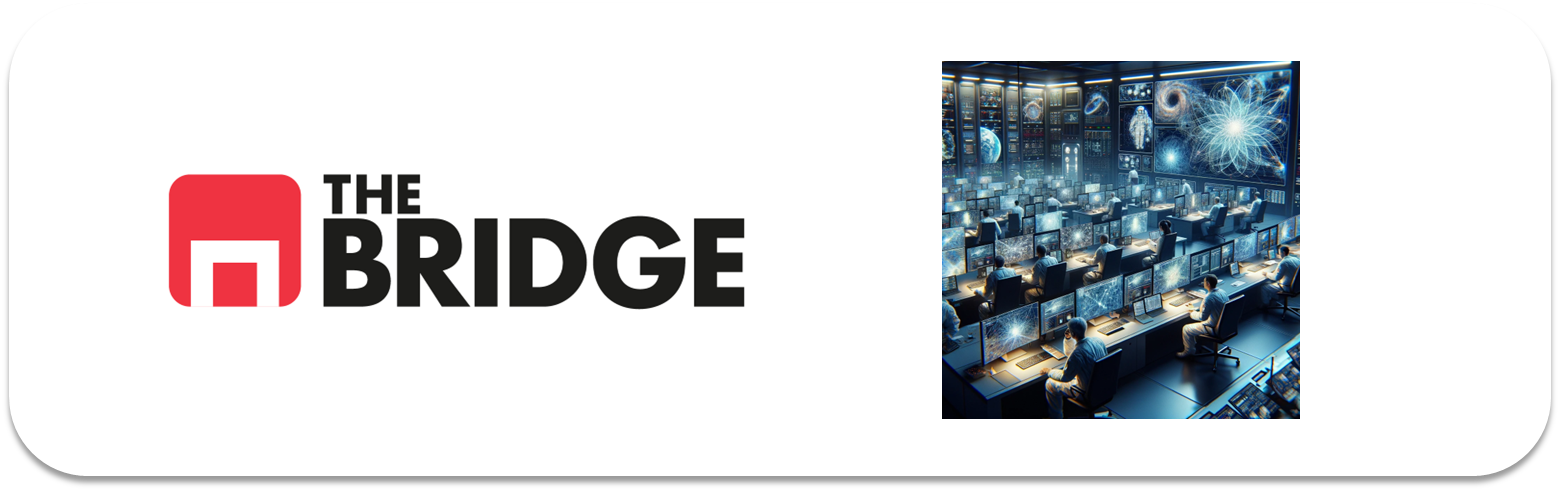

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



In [31]:
sns.set(style="whitegrid")

In [32]:
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [33]:
import os

for root, dirs, files in os.walk("."):
    if len(dirs) > 0:
        print(root, "->", dirs[:5])

. -> ['data']
.\data -> ['github_test', 'github_train_0', 'github_train_1', 'github_train_2', 'github_train_3']


In [34]:
import os

base_dir = "./data"

for folder in os.listdir(base_dir):
    folder_path = os.path.join(base_dir, folder)
    if os.path.isdir(folder_path):
        print(f"\n📁 {folder}")
        print(os.listdir(folder_path)[:10])


📁 github_test
['cat.10705.jpg', 'cat.10711.jpg', 'cat.10714.jpg', 'cat.10715.jpg', 'cat.10716.jpg', 'cat.10717.jpg', 'cat.10724.jpg', 'cat.10726.jpg', 'cat.10728.jpg', 'cat.10731.jpg']

📁 github_train_0
['cat.1000.jpg', 'cat.10010.jpg', 'cat.10012.jpg', 'cat.10013.jpg', 'cat.10017.jpg', 'cat.1002.jpg', 'cat.10023.jpg', 'cat.10024.jpg', 'cat.10027.jpg', 'cat.10030.jpg']

📁 github_train_1
['cat.1.jpg', 'cat.100.jpg', 'cat.10000.jpg', 'cat.10001.jpg', 'cat.10003.jpg', 'cat.10004.jpg', 'cat.10005.jpg', 'cat.10018.jpg', 'cat.10019.jpg', 'cat.10021.jpg']

📁 github_train_2
['dog.10001.jpg', 'dog.10004.jpg', 'dog.10008.jpg', 'dog.10009.jpg', 'dog.10013.jpg', 'dog.10014.jpg', 'dog.10015.jpg', 'dog.10022.jpg', 'dog.10030.jpg', 'dog.10034.jpg']

📁 github_train_3
['dog.10000.jpg', 'dog.10002.jpg', 'dog.10005.jpg', 'dog.10006.jpg', 'dog.10007.jpg', 'dog.10010.jpg', 'dog.10011.jpg', 'dog.10016.jpg', 'dog.10017.jpg', 'dog.10019.jpg']


In [35]:
base_dir = "./data"

train_folders = [
    os.path.join(base_dir, "github_train_0"),
    os.path.join(base_dir, "github_train_1"),
    os.path.join(base_dir, "github_train_2"),
    os.path.join(base_dir, "github_train_3")
]

test_folder = os.path.join(base_dir, "github_test")

In [36]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

class_names = ["cat", "dog"]
label_map = {"cat": 0, "dog": 1}

In [37]:
def get_image_paths_and_labels(folder_list):
    filepaths = []
    labels = []
    
    for folder in folder_list:
        for fname in os.listdir(folder):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                label_str = fname.split(".")[0]   # 'cat' o 'dog'
                if label_str in label_map:
                    filepaths.append(os.path.join(folder, fname))
                    labels.append(label_map[label_str])
    
    return filepaths, labels

In [38]:
train_paths, train_labels = get_image_paths_and_labels(train_folders)
test_paths, test_labels = get_image_paths_and_labels([test_folder])

print("Número de imágenes train total:", len(train_paths))
print("Número de imágenes test:", len(test_paths))
print("Ejemplo train:", train_paths[:5], train_labels[:5])

Número de imágenes train total: 4000
Número de imágenes test: 1000
Ejemplo train: ['./data\\github_train_0\\cat.1000.jpg', './data\\github_train_0\\cat.10010.jpg', './data\\github_train_0\\cat.10012.jpg', './data\\github_train_0\\cat.10013.jpg', './data\\github_train_0\\cat.10017.jpg'] [0, 0, 0, 0, 0]


In [39]:
X_train, X_val, y_train, y_val = train_test_split(
    train_paths,
    train_labels,
    test_size=0.2,
    random_state=SEED,
    stratify=train_labels
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(test_paths))

Train: 3200
Validation: 800
Test: 1000


In [40]:
def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    return image, label

In [41]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (
    train_dataset
    .shuffle(len(X_train), seed=SEED)
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_dataset = (
    val_dataset
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_dataset = (
    test_dataset
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

TypeError: in user code:

    File "C:\Users\Rebeca\AppData\Local\Temp\ipykernel_19760\2362472390.py", line 2, in load_and_preprocess_image  *
        image = tf.io.read_file(path)

    TypeError: Input 'filename' of 'ReadFile' Op has type float32 that does not match expected type of string.


In [42]:
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_dataset = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

In [43]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (
    train_dataset
    .shuffle(len(X_train), seed=SEED)
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_dataset = (
    val_dataset
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_dataset = (
    test_dataset
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

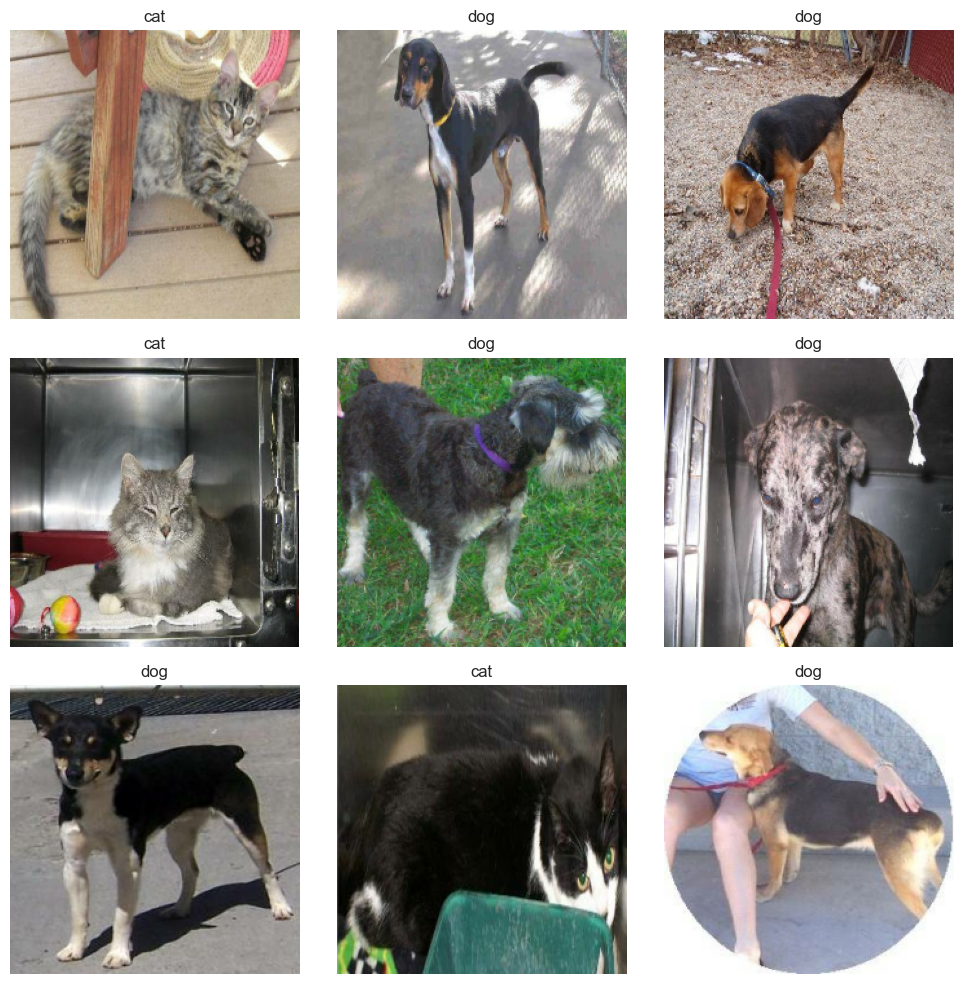

In [44]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i].numpy())])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [45]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [46]:
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [47]:
inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(2, activation="softmax")(x)

transfer_model = models.Model(inputs, outputs)

In [48]:
transfer_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [49]:
transfer_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,430,338 (9.27 MB)

 Trainable params: 172,354 (673.26 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [50]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [51]:
history_transfer = transfer_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=[early_stopping]
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 65s 609ms/step - accuracy: 0.9372 - loss: 0.1650 - val_accuracy: 0.9825 - val_loss: 0.0567
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 58s 585ms/step - accuracy: 0.9653 - loss: 0.0907 - val_accuracy: 0.9862 - val_loss: 0.0389
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 60s 605ms/step - accuracy: 0.9800 - loss: 0.0561 - val_accuracy: 0.9862 - val_loss: 0.0404
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 54s 539ms/step - accuracy: 0.9759 - loss: 0.0654 - val_accuracy: 0.9887 - val_loss: 0.0297
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 51s 514ms/step - accuracy: 0.9778 - loss: 0.0582 - val_accuracy: 0.9887 - val_loss: 0.0287
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 50s 502ms/step - accuracy: 0.9825 - loss: 0.0515 - val_accuracy: 0.9862 - val_loss: 0.0267
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 50s 503ms/step - accuracy: 0.9803 - loss: 0.0486 - val_accuracy: 0.9875 - val_loss: 0.0286
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 51s 508ms/step - accuracy: 0.9831 - loss: 0

In [52]:
def plot_history(history, title):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Train Accuracy")
    plt.plot(epochs_range, val_acc, label="Val Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Val Loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

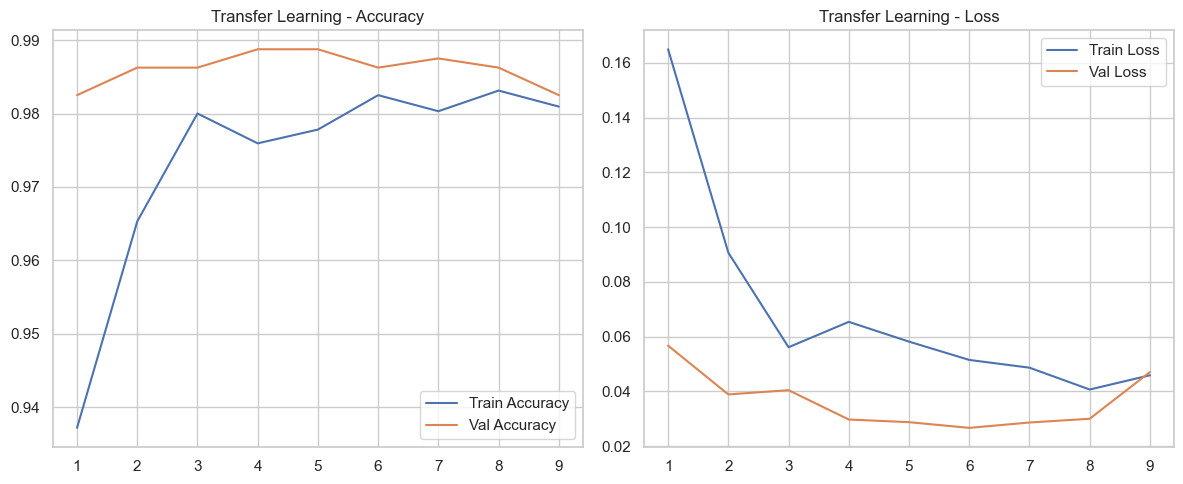

In [53]:
plot_history(history_transfer, "Transfer Learning")

In [54]:
test_loss, test_acc = transfer_model.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 377ms/step - accuracy: 0.9910 - loss: 0.0235
Test Loss: 0.0235
Test Accuracy: 0.9910


In [55]:
y_true = np.array(test_labels)
y_pred_probs = transfer_model.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 381ms/step


In [56]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

         cat       0.99      0.99      0.99       500
         dog       0.99      0.99      0.99       500

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



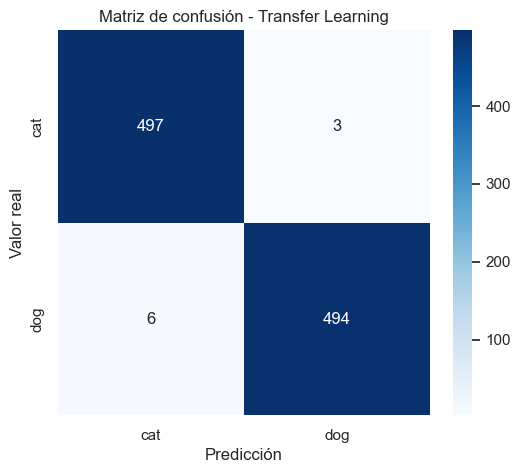

In [57]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - Transfer Learning")
plt.show()

In [58]:
base_model.trainable = True

In [59]:
fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

In [60]:
transfer_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [61]:
history_fine = transfer_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,
    callbacks=[early_stopping]
)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 84s 751ms/step - accuracy: 0.8963 - loss: 0.2988 - val_accuracy: 0.9837 - val_loss: 0.0444
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 74s 739ms/step - accuracy: 0.9578 - loss: 0.1154 - val_accuracy: 0.9875 - val_loss: 0.0357
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 74s 737ms/step - accuracy: 0.9609 - loss: 0.1044 - val_accuracy: 0.9900 - val_loss: 0.0343


In [62]:
test_loss_ft, test_acc_ft = transfer_model.evaluate(test_dataset)
print(f"Test Loss Fine Tuning: {test_loss_ft:.4f}")
print(f"Test Accuracy Fine Tuning: {test_acc_ft:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 362ms/step - accuracy: 0.9910 - loss: 0.0297
Test Loss Fine Tuning: 0.0297
Test Accuracy Fine Tuning: 0.9910


In [63]:
y_pred_probs_ft = transfer_model.predict(test_dataset)
y_pred_ft = np.argmax(y_pred_probs_ft, axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 379ms/step


In [64]:
print(classification_report(y_true, y_pred_ft, target_names=class_names))

              precision    recall  f1-score   support

         cat       0.99      0.99      0.99       500
         dog       0.99      0.99      0.99       500

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



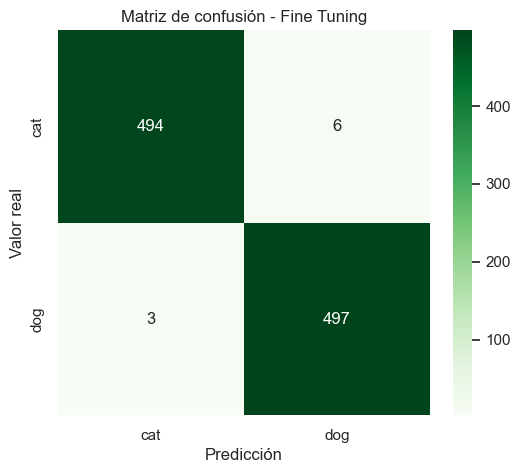

In [65]:
cm_ft = confusion_matrix(y_true, y_pred_ft)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_ft,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - Fine Tuning")
plt.show()

In [66]:
import pandas as pd

resultados = pd.DataFrame({
    "Modelo": ["CNN ad-hoc", "Transfer Learning", "Fine Tuning"],
    "Accuracy test": [0.00, test_acc, test_acc_ft]   # cambia 0.00 por tu valor real
})

resultados

,Modelo,Accuracy test
0,CNN ad-hoc,0.000
1,Transfer Learning,0.991
2,Fine Tuning,0.991


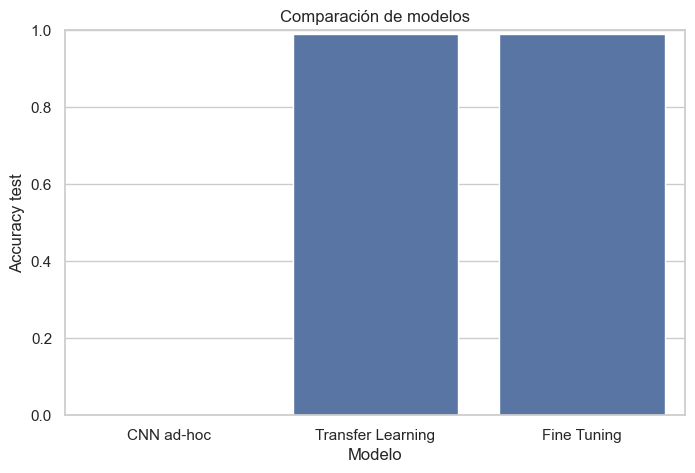

In [67]:
plt.figure(figsize=(8, 5))
sns.barplot(data=resultados, x="Modelo", y="Accuracy test")
plt.ylim(0, 1)
plt.title("Comparación de modelos")
plt.show()